# 3.4 — News: Sentiment Analysis

Data: **151 000+ articles** from 187 outlets (scraped + MediaCloud), Jul–Nov 2024, stored in `2_Silver`.

**Pipeline (following Lecture 4 — Traditional Sentiment Analysis & Lecture 5 — LLM’s for Sentiment Analysis):**
1. Load & inspect combined dataset
2. VADER sentiment analysis — lexicon-based scores per headline
3. NRCLex emotion analysis — 8-emotion profile per headline
4. Pre-trained RoBERTa sentiment — transformer-based (random sample, optional)
5. Cross-leaning sentiment comparison & visualisation
6. Sentiment over time — daily trajectories per political leaning
7. Feature engineering & export — daily basetable features

<!-- toc -->
## Contents
- [── 1. Load & inspect ─────────────────────────────────────────────────────────────────](#1-load-inspect)
- [── 2. VADER Sentiment Analysis ────────────────────────────────────────────────────](#2-vader-sentiment-analysis)
- [── 3. NRCLex Emotion Analysis ──────────────────────────────────────────────────](#3-nrclex-emotion-analysis)
- [── 5. Feature Engineering & Export ────────────────────────────────────────────](#5-feature-engineering-export)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nrclex import NRCLex

# ── Paths ────────────────────────────────────────────────────────────────────────────────
DATA   = Path('../../Data/2_Silver/Newspapers/Storage/newspaper_articles_combined.csv')
SILVER = Path('../../Data/2_Silver/Newspapers/Storage')

# ── Colour & label mappings ─────────────────────────────────────────────────────────
LEANING_COLORS = {
    'Democratic':     '#3B82F6',
    'Republican':     '#EF4444',
    'Center/Unknown': '#6B7280',
}
LEANING_SHORT = {
    'Democratic':     'dem',
    'Republican':     'rep',
    'Center/Unknown': 'cen',
}

# ── 1. Load & inspect ─────────────────────────────────────────────────────────────────

In [2]:
df = pd.read_csv(DATA, parse_dates=['date'])

print(f'Total articles : {len(df):,}')
print(f'Date range     : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Unique sources : {df["source"].nunique()}\n')
print(df.groupby('leaning').size().sort_values(ascending=False).to_string())

df.head(3)

Total articles : 159,215
Date range     : 2024-07-05 → 2024-11-04
Unique sources : 187

leaning
Center/Unknown    68214
Democratic        57847
Republican        33154


,source,leaning,date,title,url
0,The Guardian,Democratic,2024-07-05,Ukraine war briefing: Ukrainian army confirms ...,https://www.theguardian.com/world/article/2024...
1,NY Post,Republican,2024-07-05,ABC interview proves that Joe Biden is in comp...,https://nypost.com/2024/07/05/opinion/abc-inte...
2,NY Post,Republican,2024-07-05,Fourth Democratic House member calls on Biden ...,https://nypost.com/2024/07/05/us-news/rep-mike...


In [3]:
# Drop rows without a title; keep only the three main leanings
df = df.dropna(subset=['title']).copy()
df = df[df['leaning'].isin(LEANING_COLORS)].copy()
df = df.sort_values('date').reset_index(drop=True)

print(f'Articles after cleaning : {len(df):,}')
print(df['leaning'].value_counts().to_string())

Articles after cleaning : 159,215
leaning
Center/Unknown    68214
Democratic        57847
Republican        33154


# ── 2. VADER Sentiment Analysis ────────────────────────────────────────────────────

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based model that handles
capitalisation, punctuation, negations, and degree modifiers — well suited for short news
headlines (following **Lecture 4 — Traditional Sentiment Analysis**).

Output columns:
- `vader_compound` — normalised composite score ∈ [−1, 1]
- `vader_pos`, `vader_neg`, `vader_neu` — proportional scores

Classification thresholds (standard VADER convention):
- **positive** : compound ≥ 0.05
- **negative** : compound ≤ −0.05
- **neutral**  : −0.05 < compound < 0.05

In [4]:
vader = SentimentIntensityAnalyzer()

def vader_scores(text):
    scores = vader.polarity_scores(str(text))
    return scores['compound'], scores['pos'], scores['neg'], scores['neu']

(
    df['vader_compound'],
    df['vader_pos'],
    df['vader_neg'],
    df['vader_neu'],
) = zip(*df['title'].map(vader_scores))

# Classify as positive / negative / neutral (standard VADER thresholds)
def vader_label(compound):
    if compound >=  0.05: return 'positive'
    if compound <= -0.05: return 'negative'
    return 'neutral'

df['vader_label'] = df['vader_compound'].map(vader_label)

print('VADER score distribution (overall):')
print(df['vader_label'].value_counts(normalize=True).mul(100).round(1).to_string())
print(f'\nMean compound score : {df["vader_compound"].mean():+.4f}')
print(f'Std  compound score : {df["vader_compound"].std():.4f}')

VADER score distribution (overall):
vader_label
neutral     37.0
negative    36.2
positive    26.8

Mean compound score : -0.0590
Std  compound score : 0.3782


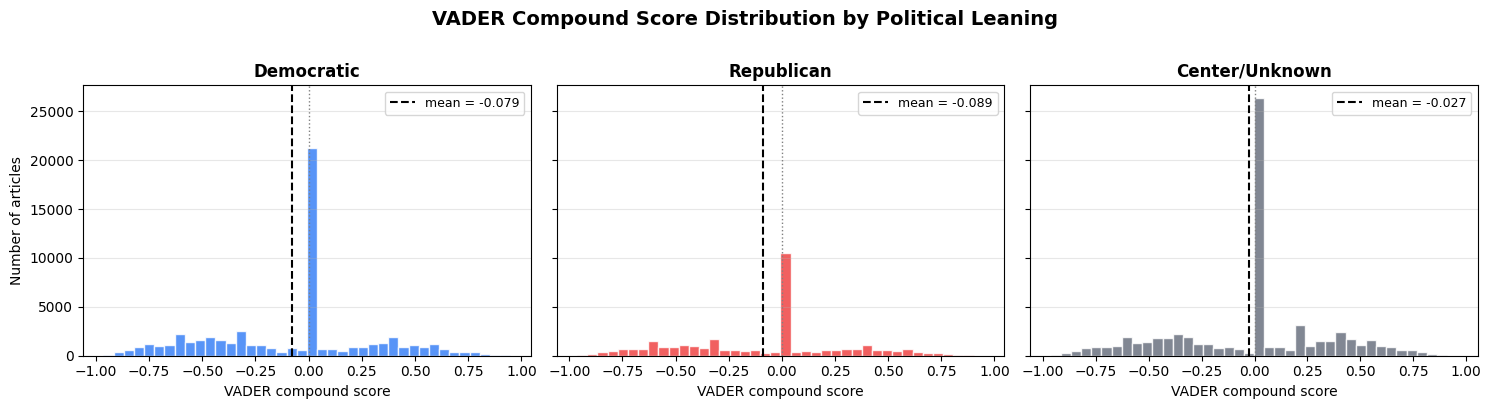

In [5]:
# ── Distribution of compound scores by leaning ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (leaning, color) in zip(axes, LEANING_COLORS.items()):
    sub = df[df['leaning'] == leaning]['vader_compound']
    ax.hist(sub, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(sub.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'mean = {sub.mean():+.3f}')
    ax.axvline(0, color='grey', linestyle=':', linewidth=1)
    ax.set_title(leaning, fontsize=12, fontweight='bold')
    ax.set_xlabel('VADER compound score')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Number of articles')
fig.suptitle('VADER Compound Score Distribution by Political Leaning',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

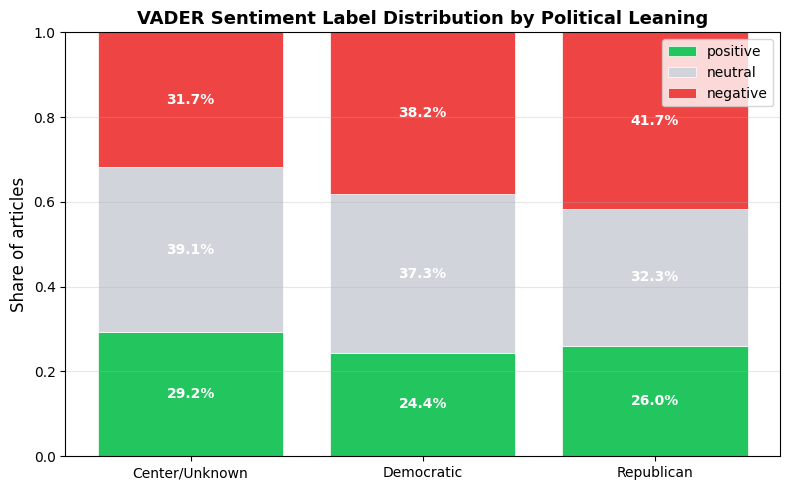

In [6]:
# ── Sentiment label shares per leaning (stacked bar) ─────────────────────────
label_shares = (
    df.groupby(['leaning', 'vader_label'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum(), axis=1)
    [['positive', 'neutral', 'negative']]
)

fig, ax = plt.subplots(figsize=(8, 5))
label_colors = {'positive': '#22C55E', 'neutral': '#D1D5DB', 'negative': '#EF4444'}

bottom = np.zeros(len(label_shares))
for label, col in label_colors.items():
    values = label_shares[label].values
    bars = ax.bar(label_shares.index, values, bottom=bottom, color=col,
                  label=label, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        if val > 0.04:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f'{val:.1%}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
    bottom += values

ax.set_ylabel('Share of articles', fontsize=12)
ax.set_title('VADER Sentiment Label Distribution by Political Leaning',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

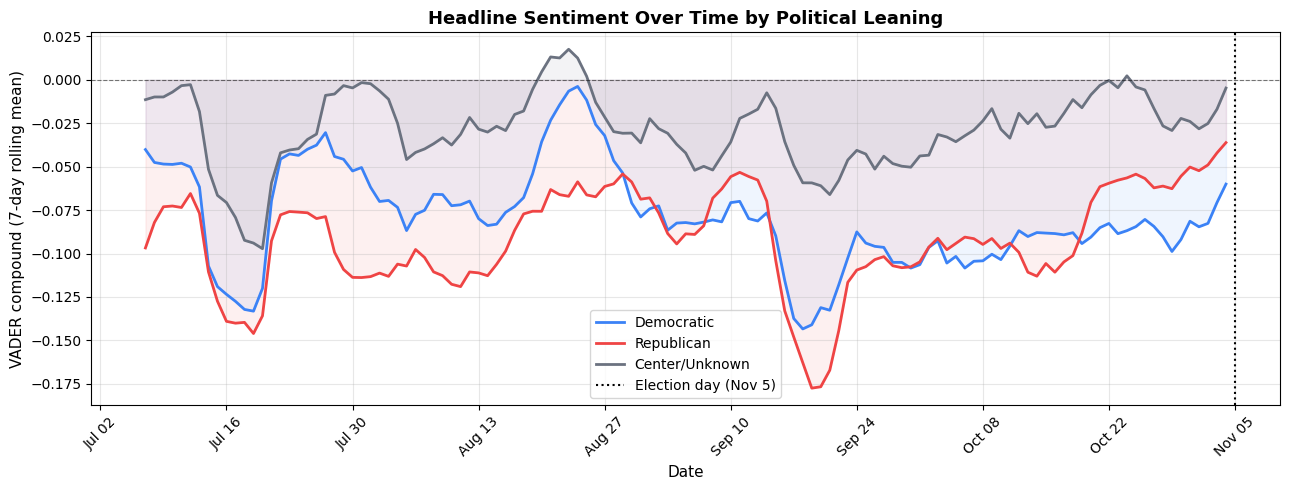

In [7]:
# ── VADER compound score over time (7-day rolling mean) ──────────────────────
daily_vader = (
    df.groupby(['date', 'leaning'])['vader_compound']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

for leaning, color in LEANING_COLORS.items():
    sub = daily_vader[daily_vader['leaning'] == leaning].set_index('date')
    rolled = sub['vader_compound'].rolling(7, min_periods=3).mean()
    ax.plot(rolled.index, rolled.values, color=color, linewidth=2, label=leaning)
    ax.fill_between(rolled.index, rolled.values, 0, color=color, alpha=0.08)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(pd.Timestamp('2024-11-05'), color='black', linestyle=':',
           linewidth=1.5, label='Election day (Nov 5)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('VADER compound (7-day rolling mean)', fontsize=11)
ax.set_title('Headline Sentiment Over Time by Political Leaning',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 3. NRCLex Emotion Analysis ──────────────────────────────────────────────────

NRCLex maps words to eight primary emotions (Plutchik’s wheel) plus positive/negative affect,
using the NRC Word–Emotion Association Lexicon (following **Lecture 4**).

| Emotion | Description |
|---------|-------------|
| `fear` | worry, dread, anxiety |
| `anger` | outrage, rage, hostility |
| `anticipation` | expectation, interest |
| `trust` | acceptance, confidence |
| `surprise` | amazement, astonishment |
| `sadness` | grief, sorrow |
| `disgust` | revulsion, loathing |
| `joy` | happiness, elation |

In [8]:
EMOTIONS = ['fear', 'anger', 'anticipation', 'trust',
            'surprise', 'sadness', 'disgust', 'joy']

def nrc_scores(text):
    """Return NRCLex affect frequencies for a headline (8 emotions)."""
    freq = NRCLex(str(text)).affect_frequencies
    return {e: freq.get(e, 0.0) for e in EMOTIONS}

print('Running NRCLex on all headlines ...')
nrc_df = df['title'].apply(nrc_scores).apply(pd.Series)

for col in nrc_df.columns:
    df[f'nrc_{col}'] = nrc_df[col].values

nrc_cols = [f'nrc_{e}' for e in EMOTIONS]
print('Done.  Sample output:')
df[['title'] + nrc_cols].head(4)

Running NRCLex on all headlines ...
Done.  Sample output:


,title,nrc_fear,nrc_anger,nrc_anticipation,nrc_trust,nrc_surprise,nrc_sadness,nrc_disgust,nrc_joy
0,Ukraine war briefing: Ukrainian army confirms ...,0.5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,France can argue later – now everyone who care...,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0
2,"Police, poverty and populism: how Perpignan be...",0.2,0.200000,0.0,0.0,0.0,0.2,0.2,0.0
3,‘Keir we go’: what the UK papers say as Labour...,0.2,0.000000,0.0,0.2,0.0,0.2,0.0,0.0


C:\Users\ninav\AppData\Local\Temp\ipykernel_32156\1228088891.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EMOTIONS, rotation=40, ha='right', fontsize=9)
C:\Users\ninav\AppData\Local\Temp\ipykernel_32156\1228088891.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EMOTIONS, rotation=40, ha='right', fontsize=9)
C:\Users\ninav\AppData\Local\Temp\ipykernel_32156\1228088891.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EMOTIONS, rotation=40, ha='right', fontsize=9)


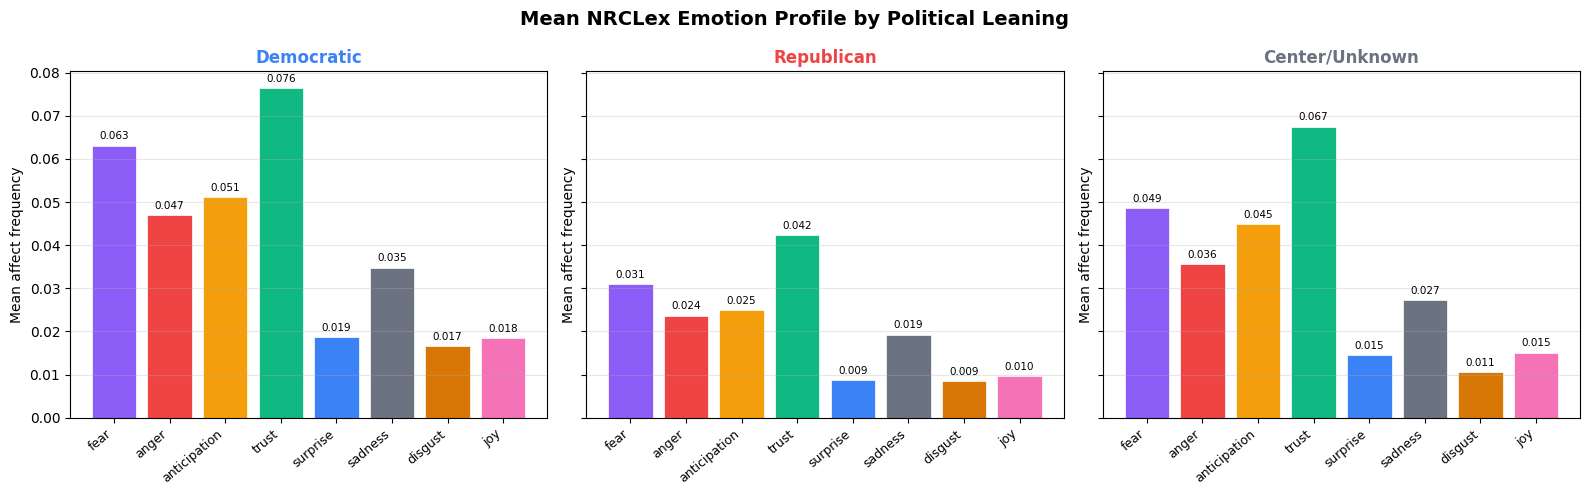

In [9]:
# ── Mean emotion profile per leaning ──────────────────────────────────────────
EMOTION_COLORS = {
    'fear': '#8B5CF6', 'anger': '#EF4444', 'anticipation': '#F59E0B',
    'trust': '#10B981', 'surprise': '#3B82F6', 'sadness': '#6B7280',
    'disgust': '#D97706', 'joy': '#F472B6',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (leaning, lean_color) in zip(axes, LEANING_COLORS.items()):
    sub = df[df['leaning'] == leaning]
    means = sub[[f'nrc_{e}' for e in EMOTIONS]].mean()
    means.index = EMOTIONS

    colors = [EMOTION_COLORS[e] for e in EMOTIONS]
    bars = ax.bar(EMOTIONS, means.values, color=colors, edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_title(leaning, fontsize=12, fontweight='bold', color=lean_color)
    ax.set_xticklabels(EMOTIONS, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Mean affect frequency')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Mean NRCLex Emotion Profile by Political Leaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

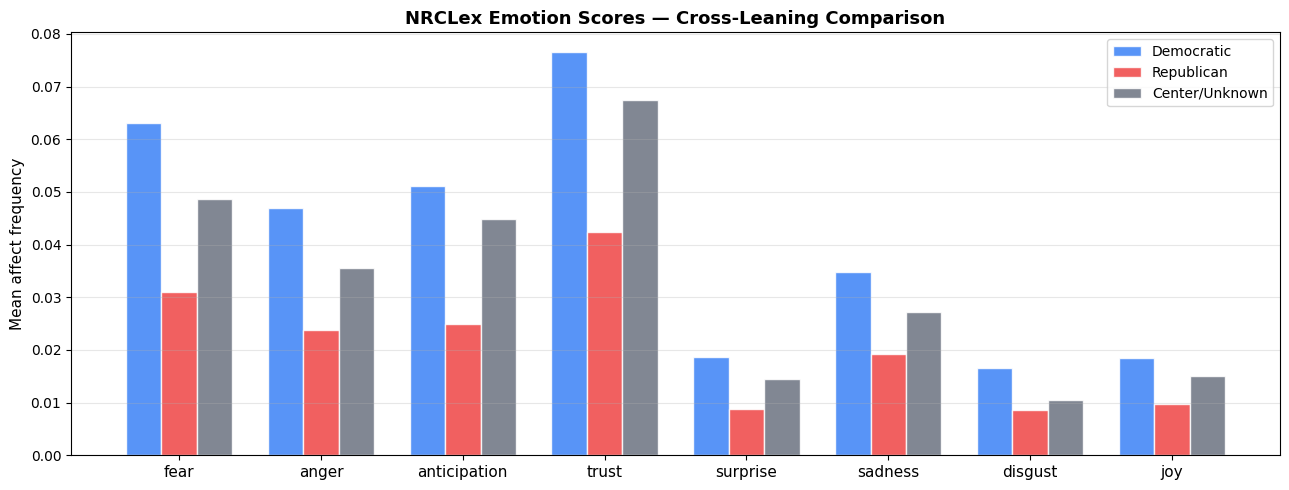


Mean emotion scores by leaning:
leaning       Center/Unknown  Democratic  Republican
fear                  0.0486      0.0630      0.0310
anger                 0.0356      0.0469      0.0237
anticipation          0.0449      0.0511      0.0249
trust                 0.0674      0.0765      0.0423
surprise              0.0145      0.0187      0.0088
sadness               0.0272      0.0348      0.0193
disgust               0.0106      0.0166      0.0085
joy                   0.0151      0.0184      0.0097


In [10]:
# ── Cross-leaning comparison for each emotion ────────────────────────────────
emotion_means = (
    df.groupby('leaning')[[f'nrc_{e}' for e in EMOTIONS]]
    .mean().T
)
emotion_means.index = EMOTIONS

x = np.arange(len(EMOTIONS))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, (leaning, color) in enumerate(LEANING_COLORS.items()):
    offset = (i - 1) * width
    ax.bar(x + offset, emotion_means[leaning], width,
           label=leaning, color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(EMOTIONS, fontsize=11)
ax.set_ylabel('Mean affect frequency', fontsize=11)
ax.set_title('NRCLex Emotion Scores — Cross-Leaning Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nMean emotion scores by leaning:')
print(emotion_means.round(4).to_string())

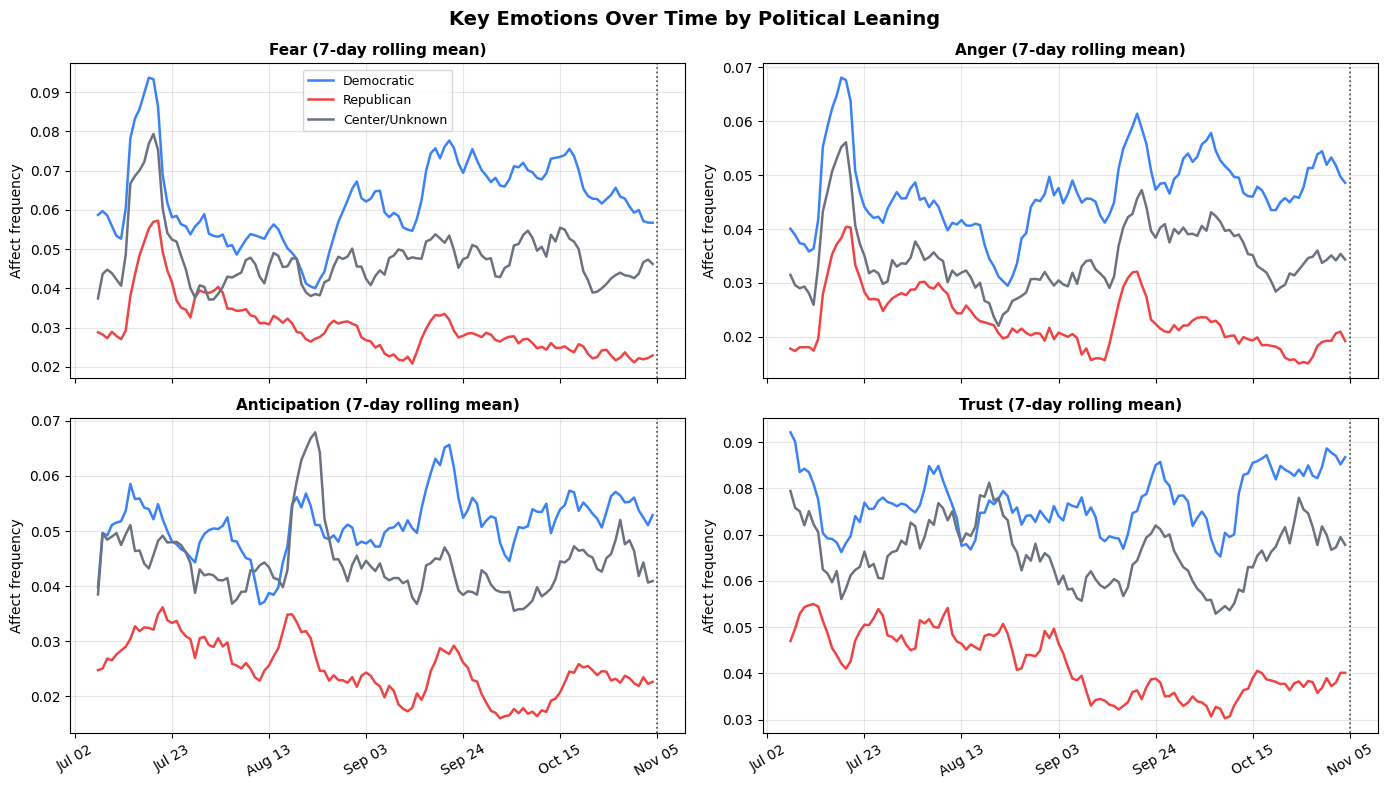

In [11]:
# ── Key emotions over time (7-day rolling mean) ─────────────────────────────
TRACK_EMOTIONS = ['fear', 'anger', 'anticipation', 'trust']

daily_nrc = (
    df.groupby(['date', 'leaning'])[[f'nrc_{e}' for e in TRACK_EMOTIONS]]
    .mean().reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, emotion in zip(axes.flat, TRACK_EMOTIONS):
    col = f'nrc_{emotion}'
    for leaning, color in LEANING_COLORS.items():
        sub = (
            daily_nrc[daily_nrc['leaning'] == leaning]
            .set_index('date')[col]
            .rolling(7, min_periods=3).mean()
        )
        ax.plot(sub.index, sub.values, color=color, linewidth=1.8, label=leaning)

    ax.axvline(pd.Timestamp('2024-11-05'), color='black', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.set_title(f'{emotion.capitalize()} (7-day rolling mean)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Affect frequency')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=3))

axes[0][0].legend(fontsize=9)
for ax in axes[1]:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

fig.suptitle('Key Emotions Over Time by Political Leaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Feature Engineering & Export ────────────────────────────────────────────

Aggregate VADER and NRCLex scores to **daily × leaning** features for the prediction
basetable (same format as `nlp_features_newspapers.csv` from notebook 5).

| Feature group | Columns | Total |
|---|---|---|
| VADER compound mean | `vader_compound_mean_{dem/rep/cen}` | 3 |
| VADER compound std | `vader_compound_std_{dem/rep/cen}` | 3 |
| VADER positive share | `vader_pos_share_{dem/rep/cen}` | 3 |
| VADER negative share | `vader_neg_share_{dem/rep/cen}` | 3 |
| NRCLex 8 emotions | `nrc_{emotion}_mean_{dem/rep/cen}` | 24 |
| **Total** | | **36 features** |

In [12]:
# ── 5a. Pivot helper ───────────────────────────────────────────────────────────────────
def pivot_leaning(long_df, value_cols):
    """Pivot daily long-format DataFrame to wide format with leaning suffixes."""
    frames = []
    for col in value_cols:
        for leaning, short in LEANING_SHORT.items():
            sub = long_df[long_df['leaning'] == leaning][['date', col]].copy()
            sub = sub.rename(columns={col: f'{col}_{short}'})
            frames.append(sub.set_index('date'))
    return pd.concat(frames, axis=1)

In [13]:
# ── 5b. VADER daily aggregations ───────────────────────────────────────────────────
df['vader_is_pos'] = (df['vader_label'] == 'positive').astype(float)
df['vader_is_neg'] = (df['vader_label'] == 'negative').astype(float)

vader_agg = (
    df.groupby(['date', 'leaning'])
    .agg(
        vader_compound_mean=('vader_compound', 'mean'),
        vader_compound_std =('vader_compound', 'std'),
        vader_pos_share    =('vader_is_pos',   'mean'),
        vader_neg_share    =('vader_is_neg',   'mean'),
    )
    .reset_index()
)

vader_wide = pivot_leaning(
    vader_agg,
    ['vader_compound_mean', 'vader_compound_std', 'vader_pos_share', 'vader_neg_share']
)

print(f'VADER feature matrix : {vader_wide.shape}')
vader_wide.head(3)

VADER feature matrix : (123, 12)


,vader_compound_mean_dem,vader_compound_mean_rep,vader_compound_mean_cen,vader_compound_std_dem,vader_compound_std_rep,vader_compound_std_cen,vader_pos_share_dem,vader_pos_share_rep,vader_pos_share_cen,vader_neg_share_dem,vader_neg_share_rep,vader_neg_share_cen
date,,,,,,,,,,,,
2024-07-05,-0.025467,-0.086731,-0.003413,0.398418,0.359468,0.390944,0.282383,0.234146,0.294944,0.331606,0.385366,0.342697
2024-07-06,-0.106401,-0.107589,-0.012802,0.377955,0.347727,0.376017,0.214953,0.231481,0.271186,0.443925,0.388889,0.344633
2024-07-07,0.011403,-0.096081,-0.018080,0.345080,0.373609,0.343613,0.276923,0.237624,0.283237,0.292308,0.435644,0.323699


In [14]:
# ── 5c. NRCLex daily aggregations ───────────────────────────────────────────────────
nrc_agg_spec = {f'nrc_{e}': (f'nrc_{e}', 'mean') for e in EMOTIONS}

nrc_agg = (
    df.groupby(['date', 'leaning'])
    .agg(**nrc_agg_spec)
    .reset_index()
)

nrc_wide = pivot_leaning(nrc_agg, [f'nrc_{e}' for e in EMOTIONS])

print(f'NRCLex feature matrix : {nrc_wide.shape}')
nrc_wide.head(3)

NRCLex feature matrix : (123, 24)


,nrc_fear_dem,nrc_fear_rep,nrc_fear_cen,nrc_anger_dem,nrc_anger_rep,nrc_anger_cen,nrc_anticipation_dem,nrc_anticipation_rep,nrc_anticipation_cen,nrc_trust_dem,...,nrc_surprise_cen,nrc_sadness_dem,nrc_sadness_rep,nrc_sadness_cen,nrc_disgust_dem,nrc_disgust_rep,nrc_disgust_cen,nrc_joy_dem,nrc_joy_rep,nrc_joy_cen
date,,,,,,,,,,,,,,,,,,,,,
2024-07-05,0.066117,0.030202,0.050810,0.037972,0.017072,0.039504,0.054247,0.023424,0.048891,0.079811,...,0.016497,0.036477,0.020604,0.028961,0.013707,0.010200,0.008116,0.020851,0.007435,0.018028
2024-07-06,0.060560,0.028824,0.033771,0.045895,0.024356,0.029903,0.026278,0.020370,0.023579,0.088679,...,0.005746,0.041898,0.030753,0.022323,0.014829,0.016035,0.003343,0.010060,0.008201,0.004704
2024-07-07,0.049473,0.027558,0.027794,0.036280,0.012046,0.025096,0.038944,0.030528,0.043030,0.107874,...,0.009289,0.033498,0.018399,0.022977,0.009019,0.004620,0.007033,0.018279,0.002228,0.009078


In [15]:
# ── 5d. Combine & save ─────────────────────────────────────────────────────────────────
sentiment_features = (
    vader_wide
    .join(nrc_wide, how='outer')
    .sort_index()
    .reset_index()
)

out_path = SILVER / 'sentiment_features_newspapers.csv'
sentiment_features.to_csv(out_path, index=False)

n_feat = sentiment_features.shape[1] - 1
print(f'Saved  -> {out_path}')
print(f'Shape  : {sentiment_features.shape}  ({n_feat} features + date)')
print(f'Dates  : {sentiment_features["date"].min().date()} -> {sentiment_features["date"].max().date()}')
print(f'\nFeature groups:')
print(f'  VADER (compound mean, std, pos/neg share) x 3 leanings : {4 * 3:>3} columns')
print(f'  NRCLex (8 emotions x mean) x 3 leanings               : {8 * 3:>3} columns')
print(f'  Total (excl. date)                                      : {n_feat:>3} columns')

sentiment_features.head(3)

Saved  -> ..\..\Data\2_Silver\Newspapers\Storage\sentiment_features_newspapers.csv
Shape  : (123, 37)  (36 features + date)
Dates  : 2024-07-05 -> 2024-11-04

Feature groups:
  VADER (compound mean, std, pos/neg share) x 3 leanings :  12 columns
  NRCLex (8 emotions x mean) x 3 leanings               :  24 columns
  Total (excl. date)                                      :  36 columns


,date,vader_compound_mean_dem,vader_compound_mean_rep,vader_compound_mean_cen,vader_compound_std_dem,vader_compound_std_rep,vader_compound_std_cen,vader_pos_share_dem,vader_pos_share_rep,vader_pos_share_cen,...,nrc_surprise_cen,nrc_sadness_dem,nrc_sadness_rep,nrc_sadness_cen,nrc_disgust_dem,nrc_disgust_rep,nrc_disgust_cen,nrc_joy_dem,nrc_joy_rep,nrc_joy_cen
0,2024-07-05,-0.025467,-0.086731,-0.003413,0.398418,0.359468,0.390944,0.282383,0.234146,0.294944,...,0.016497,0.036477,0.020604,0.028961,0.013707,0.010200,0.008116,0.020851,0.007435,0.018028
1,2024-07-06,-0.106401,-0.107589,-0.012802,0.377955,0.347727,0.376017,0.214953,0.231481,0.271186,...,0.005746,0.041898,0.030753,0.022323,0.014829,0.016035,0.003343,0.010060,0.008201,0.004704
2,2024-07-07,0.011403,-0.096081,-0.018080,0.345080,0.373609,0.343613,0.276923,0.237624,0.283237,...,0.009289,0.033498,0.018399,0.022977,0.009019,0.004620,0.007033,0.018279,0.002228,0.009078


In [16]:
# ── 5e. Coverage check ────────────────────────────────────────────────────────────────
missing = sentiment_features.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print('No missing values — all dates covered for all leanings.')
else:
    print('Columns with missing values (days where a leaning had no articles):')
    print(missing.to_string())

No missing values — all dates covered for all leanings.
